In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [4]:
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [7]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

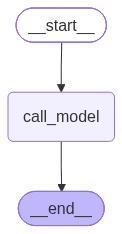

In [8]:
graph

In [10]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Ansh."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 39
Hi, my name is Nitish.
Hello Nitish! Nice to meet you. How can I assist you today?
Hi, my name is Ansh.


'Hi Ansh! Nice to meet you. How can I help you today?'

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 68
Hi, my name is Nitish.
Hello Nitish! Nice to meet you. How can I assist you today?
Hi, my name is Ansh.
Hi Ansh! Nice to meet you. How can I help you today?
I am learning LangGraph.


'That’s great! LangGraph is a powerful library for building **state‑driven, multi‑step LLM applications** (often called “agentic workflows”). It lets you define a graph of **nodes** (functions, prompts, or other actions) and the **edges** (transitions) that dictate how data moves from one step to the next, all while keeping track of a mutable **state** object.\n\nBelow is a quick rundown to get you started, plus some resources and a minimal example you can run right away.\n\n---\n\n## 1️⃣ Core Concepts\n\n| Concept | What it is | Typical use |\n|---------|------------|-------------|\n| **Node** | A callable (function, prompt, tool, etc.) that receives the current `state` and returns an updated `state` (or a partial dict). | Generate a response, call an external API, run a Python tool, etc. |\n| **Edge / Transition** | A rule that decides which node to run next, based on the current state. Often expressed as a **router** function that returns the name of the next node. | Branching logic

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'**Short‑term memory (STM)** is a temporary storage system that holds a limited amount of information for a brief period—typically on the order of seconds to a minute—while we are actively using or processing that information. It is one of the core components of the broader memory system, which also includes long‑term memory (LTM) and sensory memory.\n\nBelow is an overview of the main features, mechanisms, and research findings related to short‑term memory.\n\n---\n\n## 1. Core Characteristics\n\n| Feature | Description |\n|---------|-------------|\n| **Capacity** | Classic studies (e.g., George Miller’s “The Magical Number Seven, Plus or Minus Two”) suggest that STM can hold about **7\u202f±\u202f2 chunks** of information. More recent work using the “change detection” paradigm indicates a more conservative capacity of **3‑4 items** when items are simple (e.g., colored squares). |\n| **Duration** | Without rehearsal, information decays rapidly, typically **within 15‑30\u202fseconds**.

In [13]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I don’t have any information about your name. If you’d like to share it, feel free to let me know!'

In [25]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Nitish.
------------------------------------------------------------------------------------------------------------------------
Hello Nitish! How can I help you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's great to hear! LangGraph is a fascinating topic. What specifically would you like to learn or discuss about LangGraph? Feel free to ask any questions you may have.
------------------------------------------------------------------------------------------------------------------------
Can you explain short term memory?
------------------------------------------------------------------------------------------------------------------------
Of course! Short-term memory, also known as working memory, refers to the temporary storage and manip